---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

## Aula 01: O que é uma rede neural?

Esta aula tem por objetivo introduzir conceitos fundamentais sobre redes neurais, aprendizado de máquina e conceitos que serão úteis para todos os demais passsos. O roteiro de aula será o seguinte:

1. Apresentação geral.
2. Como escrever um neurônio artifical?
3. O que caracteriza uma rede neural?
4. Construção de uma rede neural.
5. Aplicação com dados.
6. Avaliação de resultados.

---

### 1. Apresentação Geral

Antes de definir formalmente uma rede neural, vale observar como esse campo surgiu:

- **1943 (McCulloch e Pitts):** primeira proposta matemática de um neurônio simplificado.
- **1958 (Rosenblatt):** criação do **Perceptron**, um modelo treinável para tarefas lineares.
- **1969:** críticas às limitações do perceptron desaceleram pesquisas na área.
- **Anos 1980/1990:** backpropagation e maior poder computacional retomam o interesse.
- **A partir de 2010:** GPUs, grandes bases de dados e arquiteturas profundas impulsionam o deep learning.

Com esse contexto, podemos entender a ideia central: a `rede neural artificial` é um modelo computacional inspirado no funcionamento do cérebro, composto por unidades chamadas neurônios artificiais.

De forma simples, o neurônio recebe entradas, combina essas informações com pesos e produz uma saída.

Após a soma ponderada das entradas, adiciona-se um termo de viés (*bias*), que permite ajustar o limiar de ativação do neurônio:

$$
z = \sum_{i=1}^{n} x_i w_i + b
$$

ou, de forma vetorial:

$$
z = \mathbf{w}^T \mathbf{x} + b
$$

onde:

- $\mathbf{x} = [x_1, x_2, ..., x_n]$ é o vetor de entradas  
- $\mathbf{w} = [w_1, w_2, ..., w_n]$ é o vetor de pesos  
- $b$ é o viés  
- $z$ é o potencial interno do neurônio  

Em seguida, aplica-se uma **função de ativação**, responsável por introduzir não linearidade ao modelo:

$$
a = f(z)
$$

onde:

- $f(\cdot)$ é a função de ativação  
- $a$ é a saída do neurônio  

Algumas funções de ativação comuns incluem:

**Sigmoide:**

$$
f(z) = \frac{1}{1 + e^{-z}}
$$

**ReLU (Rectified Linear Unit):**

$$
f(z) = \max(0, z)
$$

**Tangente hiperbólica:**

$$
f(z) = \tanh(z)
$$

Portanto, a forma geral de um neurônio artificial pode ser descrita como:

$$
a = f\left(\sum_{i=1}^{n} x_i w_i + b\right)
$$

Essa expressão representa o bloco fundamental que, quando organizado em múltiplas camadas interconectadas, forma uma rede neural artificial.

### O que são as funções de ativação?

As **funções de ativação** são responsáveis por transformar o valor linear calculado pelo neurônio ($z = \mathbf{w}^T \mathbf{x} + b$) em uma saída final $a$.

Elas introduzem **não linearidade** no modelo. Sem essa não linearidade, mesmo várias camadas empilhadas se comportariam como um único modelo linear, limitando severamente a capacidade da rede de aprender padrões complexos.

Em termos matemáticos:

$$
a = f(z)
$$

onde $f(\cdot)$ é a função de ativação.

As funções de ativação permitem que a rede:

- Modele relações complexas entre variáveis  
- Aprenda fronteiras de decisão não lineares  
- Capture padrões mais sofisticados nos dados  

Alguns exemplos comuns incluem:

- **Sigmoide**: usada frequentemente em problemas de classificação binária.
- **ReLU**: amplamente utilizada em redes profundas.
- **Tangente hiperbólica (tanh)**: semelhante à sigmoide, mas centrada em zero.  

Em resumo, a função de ativação é o mecanismo que torna as redes neurais capazes de aprender comportamentos complexos.

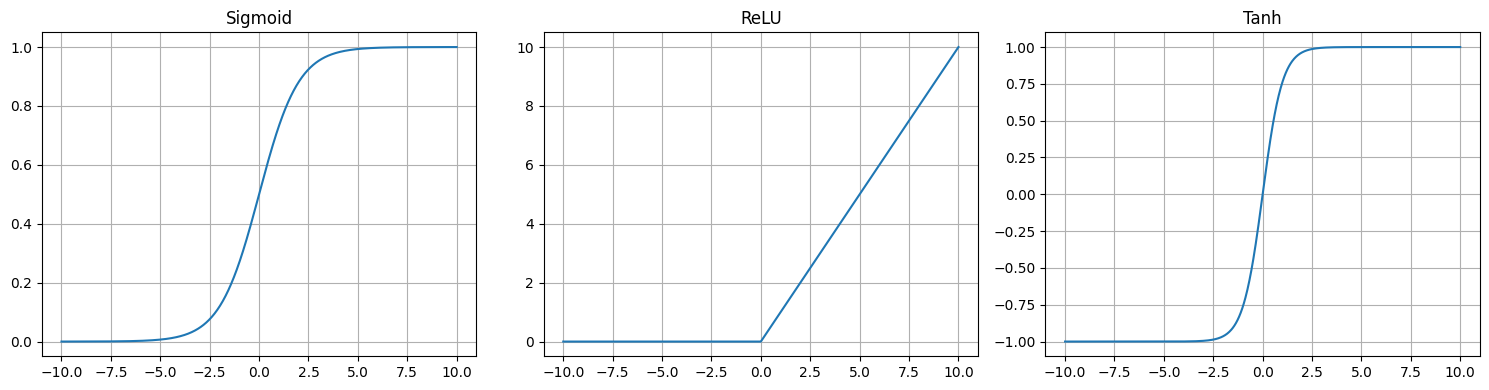

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

z = np.linspace(-10, 10, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, sigmoid(z))
axes[0].set_title("Sigmoid")
axes[0].grid(True)

axes[1].plot(z, relu(z))
axes[1].set_title("ReLU")
axes[1].grid(True)

axes[2].plot(z, tanh(z))
axes[2].set_title("Tanh")
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

### 2. Como escrever um neurônio artificial?

In [2]:
import math

def neuron(x, w, b):
    # soma ponderada
    z = 0
    for i in range(len(x)):
        z += x[i] * w[i]
    
    # adição do bias
    z += b
    # ativação
    a = sigmoid(z)
    return a


# exemplo
x = [1.0, 2.0]
w = [0.5, -1.0]
b = 0.1

saida = neuron(x, w, b)
print("Saída:", saida)

Saída: 0.19781611144141825


---

### 3. O que caracteriza uma Rede Neural?

Uma rede neural é um modelo que:

1. Possui **neurônios com pesos treináveis**  
   z = W · x + b  

2. Aplica uma **função de ativação não-linear**  
   a = f(z)

3. É organizada em **camadas**  
   Entrada → Oculta(s) → Saída

4. Possui uma **função de custo** para medir erro  

5. Aprende ajustando pesos via **backpropagation + gradiente**

### 4. Construção de uma Rede Neural:

---

### 4.1. Implementação completa da rede neural (do zero)

A seguir, consolidamos as funções necessárias para treinar uma rede neural multicamada para classificação binária:

- inicialização de pesos,
- forward propagation,
- função de custo,
- backpropagation,
- atualização de parâmetros,
- treino e predição.

---

### 4.1. Inicialização dos Pesos

A inicialização dos pesos é a etapa em que a rede neural define valores iniciais para os parâmetros treináveis, ou seja, os **pesos (W)** e os **bias (b)** de cada camada.  

Normalmente, os pesos recebem **pequenos valores aleatórios** e os bias são iniciados em **zero**, garantindo que os neurônios não comecem com comportamentos idênticos.  

Essa etapa é fundamental para permitir que o processo de treinamento ajuste corretamente os parâmetros ao longo das iterações.

In [3]:
# dim_input_layer → lista com o número de neurônios por camada
# Exemplo: [2, 4, 3, 1]
# 2 neurônios na camada de entrada
# 4 neurônios na camada oculta 1
# 3 neurônios na camada oculta 2
# 1 neurônio na camada de saída

def WeightStarter(dim_input_layer, value=0.01):
    parameters = {}
    comp = len(dim_input_layer)

    for i in range(1, comp):
        parameters["W" + str(i)] = np.random.randn(
            dim_input_layer[i], dim_input_layer[i - 1]
        ) * value

        parameters["b" + str(i)] = np.zeros((dim_input_layer[i], 1))

    return parameters

WeightStarter([2, 4, 3, 1])

{'W1': array([[-0.00466622, -0.00214429],
        [-0.00829795,  0.00377679],
        [ 0.01987464, -0.00853833],
        [-0.00422217, -0.01036471]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.]]),
 'W2': array([[ 0.00508148, -0.00026391, -0.003298  ,  0.00330768],
        [-0.00018351, -0.00052048, -0.00804381,  0.0050145 ],
        [ 0.01083074, -0.01293156, -0.00554005, -0.02098699]]),
 'b2': array([[0.],
        [0.],
        [0.]]),
 'W3': array([[ 0.00257631,  0.00140998, -0.00469696]]),
 'b3': array([[0.]])}

---

### 4.2. Funções de Ativação

As funções de ativação são responsáveis por introduzir **não-linearidade** na rede neural, permitindo que o modelo aprenda padrões complexos nos dados.  

Após a aplicação da transformação linear $Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$, a função de ativação é aplicada para gerar a saída ativada da camada.  

Sem funções de ativação não-lineares, a rede se comportaria apenas como uma combinação linear de operações, limitando sua capacidade de representação.  

Entre as funções mais comuns estão **ReLU**, utilizada nas camadas ocultas, e **Sigmoid**, frequentemente aplicada na camada de saída em problemas de classificação binária.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

---

### 4.3. Forward Propagation

A Forward Propagation é a etapa em que os dados de entrada percorrem a rede neural camada por camada até produzir uma saída.  

Nesse processo, cada camada realiza primeiro uma transformação linear definida por  
$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$  
e, em seguida, aplica uma função de ativação para gerar a nova ativação  
$A^{[l]} = f(Z^{[l]})$.  

Esse procedimento é repetido sucessivamente desde a camada de entrada até a camada de saída, resultando na predição final da rede, representada por $A^{[L]}$ ou $AL$.  

A Forward Propagation é essencial porque fornece a saída necessária para o cálculo do erro, que posteriormente será utilizado no processo de ajuste dos pesos durante o treinamento.

In [5]:
def ForwardPropagation(X, parameters):
    caches = {}
    A = X
    caches["A0"] = X
    
    L = len(parameters) // 2  # número de camadas
    
    # Camadas ocultas (ReLU)
    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        
        Z = np.dot(W, A) + b
        A = relu(Z)
        
        caches["Z" + str(l)] = Z
        caches["A" + str(l)] = A
    
    # Camada de saída (Sigmoid)
    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]
    
    ZL = np.dot(W, A) + b
    AL = sigmoid(ZL)
    
    caches["Z" + str(L)] = ZL
    caches["A" + str(L)] = AL
    
    return AL, caches

params = WeightStarter([2, 4, 3, 1])
X = np.random.randn(2, 5)  # 5 exemplos com 2 features

AL, caches = ForwardPropagation(X, params)
print(AL)

[[0.50000011 0.5000001  0.50000006 0.50000011 0.50000002]]


---

### 4.4. Função de Custo (Loss Function)

A função de custo é responsável por medir o erro entre a predição da rede neural e o valor real esperado.  

Após a Forward Propagation produzir a saída final $AL$, a função de custo calcula numericamente o quão distante essa previsão está do valor verdadeiro $Y$.  

Em problemas de classificação binária, utiliza-se com frequência a **Binary Cross-Entropy**, definida por:

$J = -\frac{1}{m} \sum \left[ Y \log(AL) + (1 - Y)\log(1 - AL) \right]$

onde $m$ representa o número de exemplos.  

A função de custo é essencial porque fornece um valor escalar que indica o desempenho da rede e serve como base para o cálculo dos gradientes no processo de Backpropagation.

In [6]:
import numpy as np

def compute_cost(AL, Y):
    m = Y.shape[1]  # número de exemplos
    
    cost = (-1 / m) * np.sum(
        Y * np.log(AL) + (1 - Y) * np.log(1 - AL)
    )
    
    return np.squeeze(cost)

AL = np.array([[0.8, 0.3, 0.9]])
Y  = np.array([[1, 0, 1]])

cost = compute_cost(AL, Y)
print(cost)

0.22839300363692283


---

### 4.5. Backpropagation

O Backpropagation é o processo responsável por calcular como cada peso da rede contribuiu para o erro obtido na função de custo. Seu objetivo é determinar os gradientes necessários para ajustar os parâmetros e reduzir o erro.  

Após o cálculo da função de custo $J$, inicia-se a propagação do erro da última camada em direção à primeira. Esse processo utiliza a regra da cadeia do cálculo diferencial para determinar as derivadas parciais da função de custo em relação aos pesos e aos bias.  

Para a camada de saída, calcula-se inicialmente:

$dAL = -\left(\frac{Y}{AL} - \frac{1 - Y}{1 - AL}\right)$

Em seguida, obtém-se:

$dZ^{[L]} = dAL \cdot f'(Z^{[L]})$

Para cada camada $l$, os gradientes são calculados como:

$dW^{[l]} = \frac{1}{m} dZ^{[l]} A^{[l-1]T}$  

$db^{[l]} = \frac{1}{m} \sum dZ^{[l]}$  

$dA^{[l-1]} = W^{[l]T} dZ^{[l]}$

Esse procedimento é repetido camada por camada, do final até o início da rede.  

O resultado do Backpropagation é o conjunto de gradientes $(dW, db)$ que serão utilizados na etapa seguinte para atualizar os pesos e minimizar a função de custo.

In [7]:
def BackPropagation(X, Y, parameters, caches):
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2

    # Saída da rede
    AL = caches["A" + str(L)]
    
    # Derivada da loss em relação a AL
    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))

    # ----- Camada de saída (Sigmoid) -----
    dZL = dAL * AL * (1 - AL)
    grads["dW" + str(L)] = (1/m) * np.dot(dZL, caches["A" + str(L-1)].T)
    grads["db" + str(L)] = (1/m) * np.sum(dZL, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(parameters["W" + str(L)].T, dZL)

    # ----- Camadas ocultas (ReLU) -----
    for l in reversed(range(1, L)):
        dZ = np.array(grads["dA" + str(l)], copy=True)
        dZ[caches["Z" + str(l)] <= 0] = 0  # derivada da ReLU
        
        grads["dW" + str(l)] = (1/m) * np.dot(dZ, caches["A" + str(l-1)].T)
        grads["db" + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        if l > 1:
            grads["dA" + str(l-1)] = np.dot(parameters["W" + str(l)].T, dZ)

    return grads

In [8]:
# uso

params = WeightStarter([2, 4, 3, 1])
X = np.random.randn(2, 5)  # 5 exemplos, 2 features
Y = np.array([[1, 0, 1, 0, 1]])

In [9]:
AL, caches = ForwardPropagation(X, params)

In [10]:
cost = compute_cost(AL, Y)
cost

np.float64(0.6931471823564046)

In [11]:
grads = BackPropagation(X, Y, params, caches)
grads

{'dW3': array([[-8.01953420e-08,  0.00000000e+00, -1.03057592e-07]]),
 'db3': array([[-0.10000007]]),
 'dA2': array([[ 0.00634579, -0.00634579,  0.00634579, -0.00634579,  0.00634579],
        [ 0.00688523, -0.00688523,  0.00688523, -0.00688523,  0.00688523],
        [ 0.00377787, -0.00377786,  0.00377786, -0.00377786,  0.00377786]]),
 'dW2': array([[ 4.69368403e-06,  1.67598474e-05, -4.37942959e-07,
          3.20068968e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 3.35432178e-06,  0.00000000e+00,  3.32866135e-06,
          1.90547994e-07]]),
 'db2': array([[0.00126916],
        [0.        ],
        [0.00075557]]),
 'dA1': array([[ 6.03200707e-07, -1.14413803e-05,  1.14413806e-05,
         -1.14413762e-05,  1.14413811e-05],
        [-4.16016487e-07, -1.16506120e-06,  1.16506124e-06,
         -1.16506078e-06,  1.16506128e-06],
        [ 7.17331535e-05, -5.75659715e-05,  5.75659733e-05,
         -5.75659509e-05,  5.75659755e-05],


In [12]:
learning_rate = 0.5

for l in range(1, len(params)//2 + 1):
    params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
    params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

In [13]:
lr = 0.5
for i in range(3000):
    AL, caches = ForwardPropagation(X, params)
    cost = compute_cost(AL, Y)
    grads = BackPropagation(X, Y, params, caches)

    for l in range(1, len(params)//2 + 1):
        params["W" + str(l)] -= lr * grads["dW" + str(l)]
        params["b" + str(l)] -= lr * grads["db" + str(l)]

    if i % 100 == 0:
        print("Iteração:", i, "Custo:", cost)

Iteração: 0 Custo: 0.6884596447995498
Iteração: 100 Custo: 0.6730116670093681
Iteração: 200 Custo: 0.6730116670092565
Iteração: 300 Custo: 0.6730116670092564
Iteração: 400 Custo: 0.6730116670092564
Iteração: 500 Custo: 0.6730116670092564
Iteração: 600 Custo: 0.6730116670092564
Iteração: 700 Custo: 0.6730116670092564
Iteração: 800 Custo: 0.6730116670092564
Iteração: 900 Custo: 0.6730116670092564
Iteração: 1000 Custo: 0.6730116670092564
Iteração: 1100 Custo: 0.6730116670092564
Iteração: 1200 Custo: 0.6730116670092564
Iteração: 1300 Custo: 0.6730116670092564
Iteração: 1400 Custo: 0.6730116670092564
Iteração: 1500 Custo: 0.6730116670092564
Iteração: 1600 Custo: 0.6730116670092564
Iteração: 1700 Custo: 0.6730116670092564
Iteração: 1800 Custo: 0.6730116670092564
Iteração: 1900 Custo: 0.6730116670092564
Iteração: 2000 Custo: 0.6730116670092564
Iteração: 2100 Custo: 0.6730116670092564
Iteração: 2200 Custo: 0.6730116670092564
Iteração: 2300 Custo: 0.6730116670092564
Iteração: 2400 Custo: 0.6730

---

### 5. Aplicação com dados

Para este estudo de caso, utilizaremos os dados de `regression_example.csv`.

In [14]:
import pandas as pd

df = pd.read_csv("data/regression_example.csv")
df.head()
df.describe()

,feature1,feature2,feature3,feature4,target
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,5.197429,5.024359,4.902299,5.016093,23.335552
std,2.882820,2.740042,2.800285,2.947727,13.370127
min,0.028356,0.034733,0.016913,0.061058,-9.328168
25%,2.600131,2.688347,2.550522,2.568386,13.824976
50%,5.307046,5.253612,4.889624,4.932685,22.713519
75%,7.672316,7.183742,7.256450,7.702533,32.522920
max,9.999078,9.945254,9.992825,9.989023,57.383132


In [15]:
def ForwardPropagation(X, parameters):
    caches = {}
    A = X
    caches["A0"] = X
    
    L = len(parameters) // 2
    
    # Camadas ocultas (ReLU)
    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        
        Z = np.dot(W, A) + b
        A = relu(Z)
        
        caches["Z" + str(l)] = Z
        caches["A" + str(l)] = A
    
    # Camada de saída (Linear para regressão)
    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]
    
    ZL = np.dot(W, A) + b
    AL = ZL
    
    caches["Z" + str(L)] = ZL
    caches["A" + str(L)] = AL
    
    return AL, caches

def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = (1/m) * np.sum((AL - Y)**2)
    return cost

def BackPropagation(X, Y, parameters, caches):
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2

    # ===== CAMADA DE SAÍDA (LINEAR) =====
    AL = caches["A" + str(L)]
    
    # Derivada da MSE: dZL = AL - Y
    dZ = AL - Y
    
    grads["dW" + str(L)] = (1/m) * np.dot(dZ, caches["A" + str(L-1)].T)
    grads["db" + str(L)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(parameters["W" + str(L)].T, dZ)

    # ===== CAMADAS OCULTAS (ReLU) =====
    for l in reversed(range(1, L)):
        dZ = np.array(grads["dA" + str(l)], copy=True)
        
        # Derivada da ReLU
        dZ[caches["Z" + str(l)] <= 0] = 0
        
        grads["dW" + str(l)] = (1/m) * np.dot(dZ, caches["A" + str(l-1)].T)
        grads["db" + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        if l > 1:
            grads["dA" + str(l-1)] = np.dot(parameters["W" + str(l)].T, dZ)

    return grads

In [16]:
X = df[["feature1", "feature2", "feature3", "feature4"]].values.T
Y = df["target"].values.reshape(1, -1)

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)

Shape X: (4, 400)
Shape Y: (1, 400)


In [17]:
params = WeightStarter([4, 10, 5, 1])
params

{'W1': array([[-1.05586500e-03, -3.88294046e-03,  1.23629913e-02,
         -3.87851189e-03],
        [-6.10133690e-03,  2.32873911e-02, -1.47941621e-02,
          7.60215921e-03],
        [ 4.20817301e-03, -8.81880317e-03, -1.04085616e-02,
          1.38689318e-02],
        [ 1.67660867e-02, -1.63415030e-02, -2.15687383e-03,
          4.29551275e-03],
        [-5.85974621e-03, -3.87467052e-02,  1.32973022e-02,
         -1.68298391e-02],
        [-5.33660112e-03, -9.00502061e-03,  3.33064370e-03,
         -5.76740926e-03],
        [-2.08082422e-02,  7.91845901e-03, -7.92054076e-03,
         -3.62315563e-03],
        [ 8.25678107e-03, -2.71802694e-02,  4.19777207e-03,
          1.09994638e-04],
        [-9.09151116e-03,  6.53349886e-03,  9.01236684e-03,
          5.72269373e-03],
        [-1.57976330e-03, -2.96318009e-03,  9.14370292e-03,
          2.32463757e-05]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
    

In [18]:
learning_rate = 0.05
epochs = 5000

cost_history = []
step_history = []

for i in range(epochs):

    AL, caches = ForwardPropagation(X, params)
    cost = compute_cost(AL, Y)
    grads = BackPropagation(X, Y, params, caches)

    for l in range(1, len(params)//2 + 1):
        params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    cost_history.append(cost)
    step_history.append(i)

    if i % 300 == 0:
        print("Epoch:", i, "Cost:", cost)

Epoch: 0 Cost: 722.860191494936
Epoch: 300 Cost: 178.31340088153098
Epoch: 600 Cost: 178.31340088149943
Epoch: 900 Cost: 178.31340088149943
Epoch: 1200 Cost: 178.31340088149943
Epoch: 1500 Cost: 178.31340088149943
Epoch: 1800 Cost: 178.31340088149943
Epoch: 2100 Cost: 178.31340088149943
Epoch: 2400 Cost: 178.31340088149943
Epoch: 2700 Cost: 178.31340088149943
Epoch: 3000 Cost: 178.31340088149943
Epoch: 3300 Cost: 178.31340088149943
Epoch: 3600 Cost: 178.31340088149943
Epoch: 3900 Cost: 178.31340088149943
Epoch: 4200 Cost: 178.31340088149943
Epoch: 4500 Cost: 178.31340088149943
Epoch: 4800 Cost: 178.31340088149943


RMSE antes dos ajustes: 13.3534


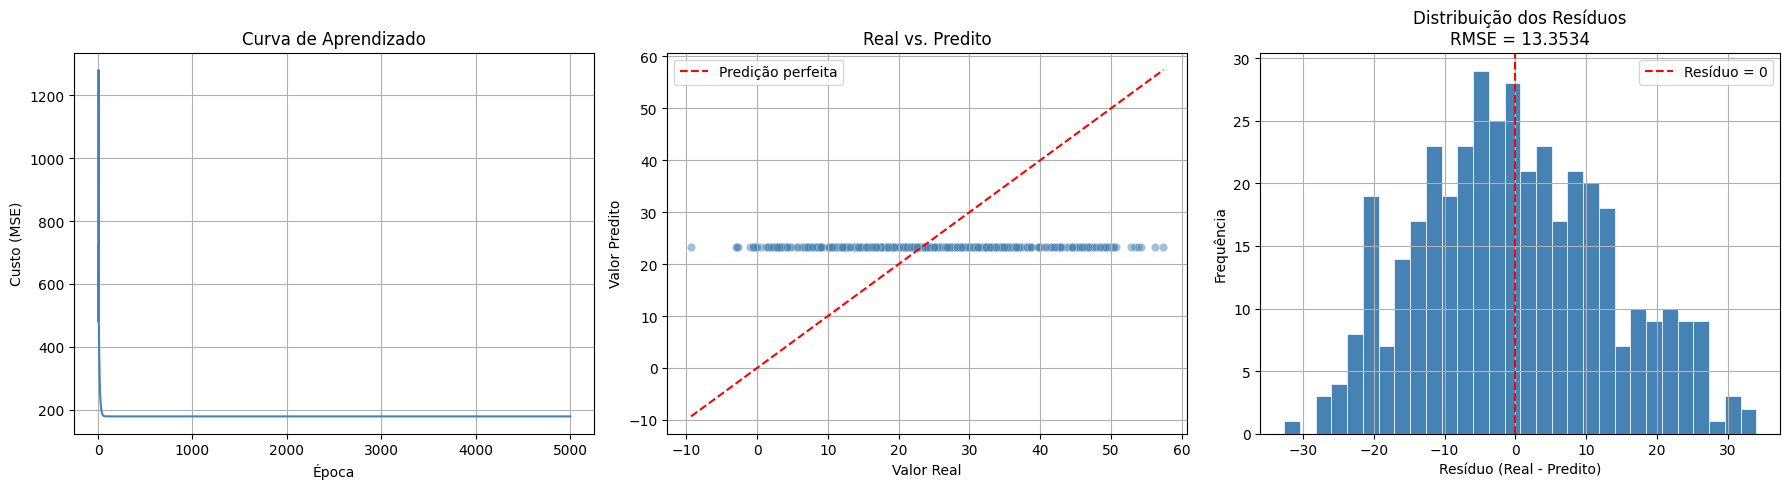

In [19]:
# Resultados antes dos ajustes (mesmos gráficos)
AL_before, _ = ForwardPropagation(X, params)

rmse_before = np.sqrt(np.mean((AL_before - Y) ** 2))
print(f"RMSE antes dos ajustes: {rmse_before:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de aprendizado
axes[0].plot(cost_history, color="steelblue", linewidth=1.5)
axes[0].set_title("Curva de Aprendizado")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Custo (MSE)")
axes[0].grid(True)

# 2. Real vs. Predito
y_real_before = Y.flatten()
y_pred_before = AL_before.flatten()
axes[1].scatter(y_real_before, y_pred_before, alpha=0.5, color="steelblue", edgecolors="white", linewidths=0.3)
min_val_before = min(y_real_before.min(), y_pred_before.min())
max_val_before = max(y_real_before.max(), y_pred_before.max())
axes[1].plot([min_val_before, max_val_before], [min_val_before, max_val_before], "r--", linewidth=1.5, label="Predição perfeita")
axes[1].set_title("Real vs. Predito")
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Valor Predito")
axes[1].legend()
axes[1].grid(True)

# 3. Distribuição dos resíduos
residuos_before = y_real_before - y_pred_before
axes[2].hist(residuos_before, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Resíduo = 0")
axes[2].set_title(f"Distribuição dos Resíduos\nRMSE = {rmse_before:.4f}")
axes[2].set_xlabel("Resíduo (Real - Predito)")
axes[2].set_ylabel("Frequência")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Perceba que podemos otimizar esses resultados

X — média após normalização: [0. 0. 0. 0.]
X — std  após normalização: [1. 1. 1. 1.]
Y — média após normalização: 0.0
Y — std  após normalização: 1.0
Epoch     0  |  Custo (MSE normalizado): 1.000003
Epoch   500  |  Custo (MSE normalizado): 0.026868
Epoch  1000  |  Custo (MSE normalizado): 0.022639
Epoch  1500  |  Custo (MSE normalizado): 0.022185
Epoch  2000  |  Custo (MSE normalizado): 0.021756
Epoch  2500  |  Custo (MSE normalizado): 0.021639
Epoch  3000  |  Custo (MSE normalizado): 0.021557
Epoch  3500  |  Custo (MSE normalizado): 0.021487
Epoch  4000  |  Custo (MSE normalizado): 0.021376
Epoch  4500  |  Custo (MSE normalizado): 0.021333

RMSE na escala original: 1.9492


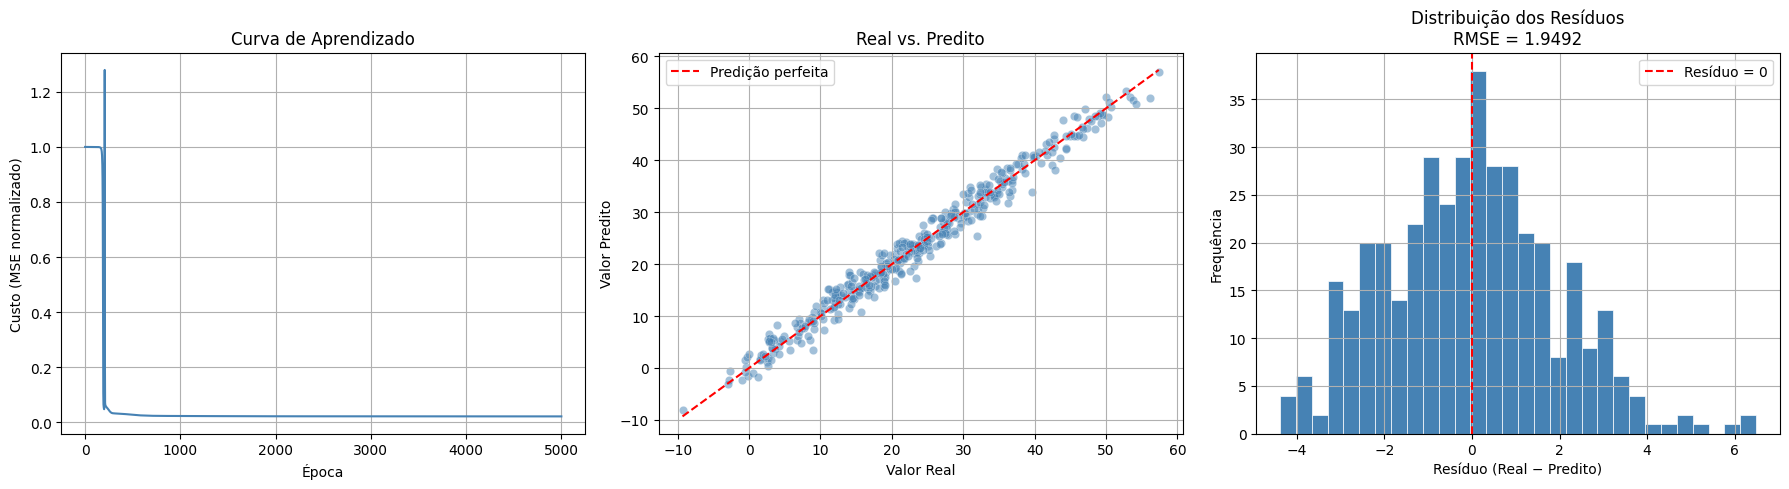

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# Normalização manual (Z-score / Padronização)
# ─────────────────────────────────────────

def normalize_fit(X):
    media = np.mean(X, axis=1, keepdims=True)
    desvio = np.std(X, axis=1, keepdims=True)
    return media, desvio

def normalize_transform(X, media, desvio):
    return (X - media) / (desvio + 1e-8)

def normalize_inverse(X_norm, media, desvio):
    return X_norm * (desvio + 1e-8) + media

# ─────────────────────────────────────────
# Carregamento e preparação dos dados
# ─────────────────────────────────────────

df = pd.read_csv("data/regression_example.csv")

X_raw = df[["feature1", "feature2", "feature3", "feature4"]].values.T
Y_raw = df["target"].values.reshape(1, -1)

media_X, desvio_X = normalize_fit(X_raw)
media_Y, desvio_Y = normalize_fit(Y_raw)

X = normalize_transform(X_raw, media_X, desvio_X)
Y = normalize_transform(Y_raw, media_Y, desvio_Y)

print("X — média após normalização:", np.mean(X, axis=1).round(4))
print("X — std  após normalização:", np.std(X,  axis=1).round(4))
print("Y — média após normalização:", np.mean(Y).round(4))
print("Y — std  após normalização:", np.std(Y).round(4))

# ─────────────────────────────────────────
# Treinamento
# ─────────────────────────────────────────

params = WeightStarter([4, 10, 5, 1])
learning_rate = 0.5
epochs = 5000
historico_custo = []

for i in range(epochs):
    AL, caches = ForwardPropagation(X, params)
    cost       = compute_cost(AL, Y)
    grads      = BackPropagation(X, Y, params, caches)

    historico_custo.append(cost)

    for l in range(1, len(params) // 2 + 1):
        params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    if i % 500 == 0:
        print(f"Epoch {i:>5}  |  Custo (MSE normalizado): {cost:.6f}")

# ─────────────────────────────────────────
# Predição na escala original
# ─────────────────────────────────────────

AL_norm, _ = ForwardPropagation(X, params)
Y_pred = normalize_inverse(AL_norm, media_Y, desvio_Y)

rmse = np.sqrt(np.mean((Y_pred - Y_raw) ** 2))
print(f"\nRMSE na escala original: {rmse:.4f}")

# ─────────────────────────────────────────
# Gráficos
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de aprendizado
axes[0].plot(historico_custo, color="steelblue", linewidth=1.5)
axes[0].set_title("Curva de Aprendizado")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Custo (MSE normalizado)")
axes[0].grid(True)

# 2. Real vs. Predito
y_real = Y_raw.flatten()
y_pred = Y_pred.flatten()
axes[1].scatter(y_real, y_pred, alpha=0.5, color="steelblue", edgecolors="white", linewidths=0.3)
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Predição perfeita")
axes[1].set_title("Real vs. Predito")
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Valor Predito")
axes[1].legend()
axes[1].grid(True)

# 3. Distribuição dos resíduos
residuos = y_real - y_pred
axes[2].hist(residuos, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Resíduo = 0")
axes[2].set_title(f"Distribuição dos Resíduos\nRMSE = {rmse:.4f}")
axes[2].set_xlabel("Resíduo (Real − Predito)")
axes[2].set_ylabel("Frequência")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

### Importância do tratamento das variáveis

A comparação entre os gráficos antes e depois da normalização mostra que o tratamento das variáveis é decisivo para a qualidade do modelo. Sem normalização, diferenças de escala entre os atributos podem dominar o processo de aprendizado, dificultando a convergência e aumentando o erro.

Ao normalizar os dados, o treinamento fica mais estável, o gradiente se comporta melhor e a rede consegue aprender padrões de forma mais eficiente. Como resultado, observamos redução do RMSE, melhor alinhamento no gráfico **Real vs. Predito** e resíduos mais concentrados em torno de zero.

Em aplicações reais, esse pré-processamento é uma etapa essencial para tornar o modelo mais preciso, robusto e confiável.